# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import itertools
from statsmodels.stats.multicomp import pairwise_tukeyhsd

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [2]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [28]:
# Correlation coefficients and p-values
numeric_df = mpg.select_dtypes(include=['float64', 'int64'])
cols = numeric_df.columns
results = []

for col1, col2 in itertools.combinations(cols, 2):

    p_corr, p_pval = pearsonr(numeric_df[col1], numeric_df[col2])

    s_corr, s_pval = spearmanr(numeric_df[col1], numeric_df[col2])
    
    results.append({
        'Pair': f"{col1} - {col2}",
        'Pearson (r)': p_corr,
        'Pearson p-value': p_pval,
        'Spearman (ρ)': s_corr,
        'Spearman p-value': s_pval
    })

summary_table = pd.DataFrame(results)

summary_table['Abs_Pearson'] = summary_table['Pearson (r)'].abs()
summary_table = summary_table.sort_values(by='Abs_Pearson', ascending=False).drop(columns=['Abs_Pearson'])

display(summary_table)

print(mpg.displacement.std())
print(mpg.horsepower.std())
print(mpg.cylinders.std())
print(mpg.weight.std())

,Pair,Pearson (r),Pearson p-value,Spearman (ρ),Spearman p-value
6,cylinders - displacement,0.950823,1.298636e-200,0.913566,1.810859e-154
12,displacement - weight,0.932994,3.489084e-175,0.945630,2.463170e-192
8,cylinders - weight,0.897527,9.290616e-141,0.875972,1.509812e-125
11,displacement - horsepower,0.897257,1.510889e-140,0.876171,1.126737e-125
15,horsepower - weight,0.864538,1.364347e-118,0.878819,2.182674e-127
7,cylinders - horsepower,0.842983,4.633884e-107,0.816188,6.065373e-95
3,mpg - weight,-0.832244,6.015296e-102,-0.875585,2.662378e-125
1,mpg - displacement,-0.805127,1.660642e-90,-0.855234,2.195778e-113
2,mpg - horsepower,-0.778427,7.031989e-81,-0.853616,1.619383e-112
0,mpg - cylinders,-0.777618,1.311384e-80,-0.823175,6.649861e-98


104.64400390890465
38.49115993282855
1.7057832474527843
849.4025600429494


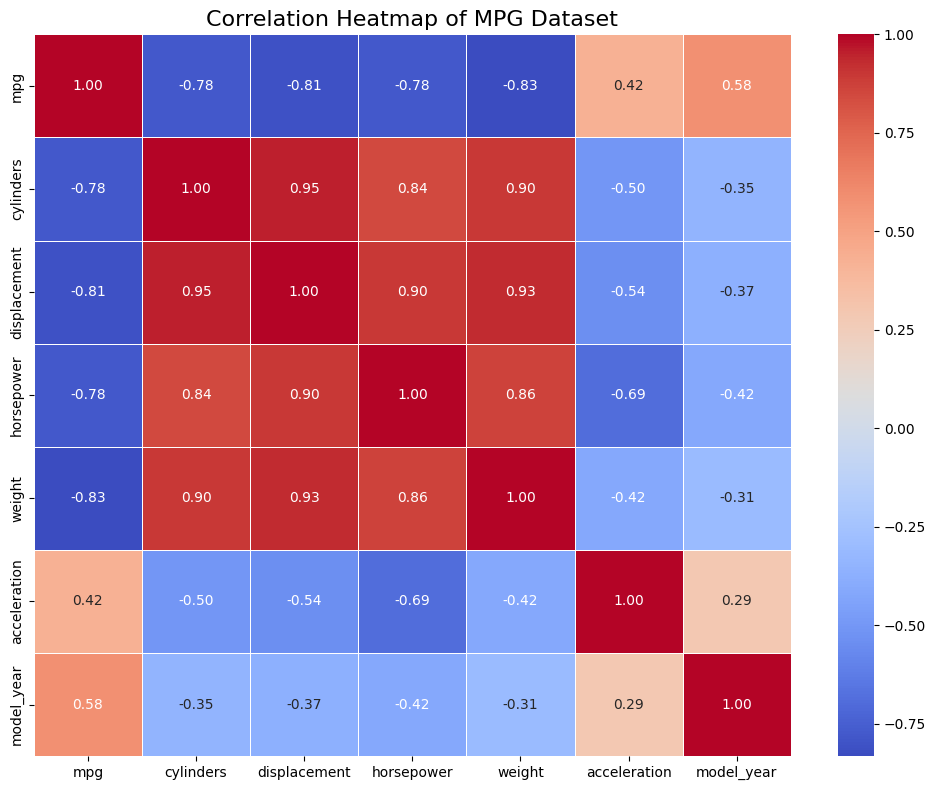

In [ ]:
plt.figure(figsize=(10, 8))

numeric_df = mpg.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of MPG Dataset', fontsize=16)
plt.tight_layout()
plt.show()

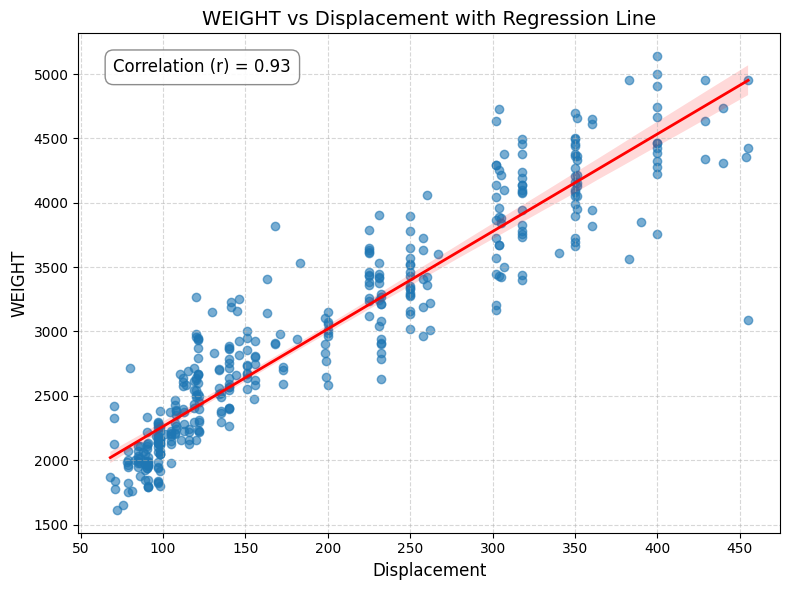

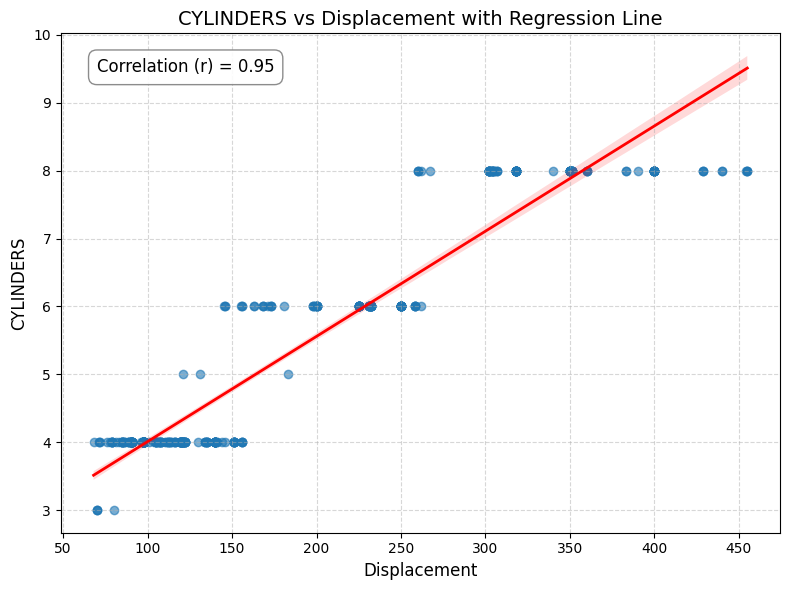

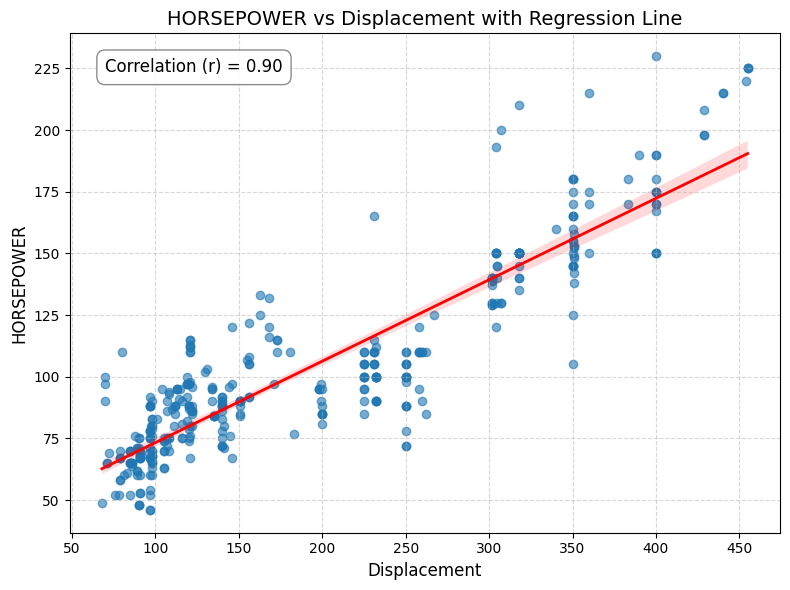

In [10]:
def plot_scatter_with_regr(x_col, y_col):
    plt.figure(figsize=(8, 6))
    
    subset = mpg[[x_col, y_col]].dropna()
    r, p_value = pearsonr(subset[x_col], subset[y_col])
    
    sns.regplot(
        data=subset, 
        x=x_col, 
        y=y_col, 
        scatter_kws={'alpha':0.6}, 
        line_kws={'color':'red', 'linewidth': 2}
    )
    
    plt.title(f'{y_col.upper()} vs {x_col.capitalize()} with Regression Line', fontsize=14)
    plt.xlabel(x_col.capitalize(), fontsize=12)
    plt.ylabel(y_col.upper(), fontsize=12)
    
    ax = plt.gca()
    plt.text(0.05, 0.95, f'Correlation (r) = {r:.2f}', 
             transform=ax.transAxes, 
             fontsize=12, 
             verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='gray'))
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_scatter_with_regr('displacement', 'weight')

plot_scatter_with_regr('displacement', 'cylinders')

plot_scatter_with_regr('displacement', 'horsepower')

### Interpretation

*When is Pearson vs. Spearman more appropriate? Use your results as examples.*

I chose cylinders-displacement, weight-displacement, horsepower-displacement pairs for 3 pairs which task requires. 


we can see pearson and spearman relationship between them and these 3 pairs are one of the highest correlated pairs. 

As we have displacement on each of the pairs, I think, it is more appropriate to use spearman values because chosen columns' standard deviation is high(exept cylinders column) and that mean's some values can highly deceive pearson test because pearson test works on raw values. that is why, we should go on with spearman values because it does rank the raw values and works on ranks

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

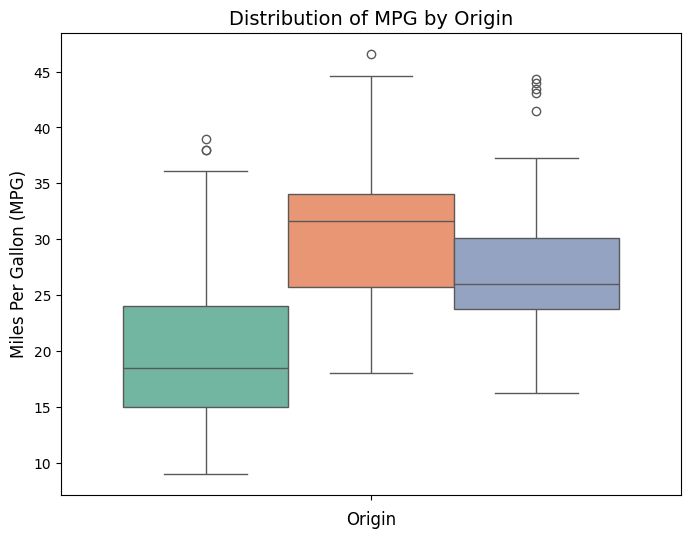

In [13]:
# Distribution visualization by origin
plt.figure(figsize=(8, 6))
sns.boxplot(y='mpg', data=mpg, palette='Set2',hue='origin',legend=False)
plt.title('Distribution of MPG by Origin', fontsize=14)
plt.xlabel('Origin', fontsize=12)
plt.ylabel('Miles Per Gallon (MPG)', fontsize=12)
plt.show()

# Separate the groups for statistical testing
usa_mpg = mpg[mpg['origin'] == 'usa']['mpg']
europe_mpg = mpg[mpg['origin'] == 'europe']['mpg']
japan_mpg = mpg[mpg['origin'] == 'japan']['mpg']

In [ ]:
print(f"Shapiro-Wilk USA: W={stats.shapiro(usa_mpg)[0]:.4f}, p={stats.shapiro(usa_mpg)[1]:.4f}")
print(f"Shapiro-Wilk Europe: W={stats.shapiro(europe_mpg)[0]:.4f}, p={stats.shapiro(europe_mpg)[1]:.4f}")
print(f"Shapiro-Wilk Japan: W={stats.shapiro(japan_mpg)[0]:.4f}, p={stats.shapiro(japan_mpg)[1]:.4f}")

stat, p_levene = stats.levene(usa_mpg, europe_mpg, japan_mpg)
print(f"\nLevene's Test: W={stat:.4f}, p={p_levene:.4f}")

Shapiro-Wilk USA: W=0.9337, p=0.0000
Shapiro-Wilk Europe: W=0.9462, p=0.0054
Shapiro-Wilk Japan: W=0.9797, p=0.2420

Levene's Test: W=0.0861, p=0.9175


In [ ]:
f_stat, p_val = stats.f_oneway(usa_mpg, europe_mpg, japan_mpg)
print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_val:.2e}")

ss_between = sum([len(g) * (g.mean() - mpg['mpg'].mean())**2 for g in [usa_mpg, europe_mpg, japan_mpg]])
ss_total = sum((mpg['mpg'] - mpg['mpg'].mean())**2)
eta_squared = ss_between / ss_total
print(f"Eta-squared (Effect Size): {eta_squared:.4f}")


ANOVA F-statistic: 96.6015
ANOVA p-value: 8.67e-35
Eta-squared (Effect Size): 0.3318


In [19]:
if p_val < 0.05:
    tukey = pairwise_tukeyhsd(endog=mpg['mpg'], groups=mpg['origin'], alpha=0.05)
    print(tukey)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


### Interpretation

*Which groups differ? What does the effect size tell you?*

As we can see from Tukey's HSD post-hoc test's output, each group differ from each other and we reject null hypothesis for each of them

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score


X = mpg.select_dtypes(include=[np.number])
y = mpg['origin']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
print("--- Logistic Regression Report ---")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
print(classification_report(y_test, lr_preds))

print("\n--- Decision Tree Report ---")
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train) 
dt_preds = dt.predict(X_test_scaled)
print(classification_report(y_test, dt_preds))


--- Logistic Regression Report ---
              precision    recall  f1-score   support

      europe       0.89      0.47      0.62        17
       japan       0.61      0.70      0.65        20
         usa       0.86      0.93      0.90        61

    accuracy                           0.81        98
   macro avg       0.79      0.70      0.72        98
weighted avg       0.82      0.81      0.80        98


--- Decision Tree Report ---
              precision    recall  f1-score   support

      europe       0.83      0.59      0.69        17
       japan       0.79      0.95      0.86        20
         usa       0.94      0.95      0.94        61

    accuracy                           0.89        98
   macro avg       0.85      0.83      0.83        98
weighted avg       0.89      0.89      0.88        98



In [ ]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42, **kwargs):
    """Computes 95% bootstrap confidence intervals for a given metric."""
    np.random.seed(seed)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    boot_metrics = []
    
    for _ in range(n_boot):
        indices = np.random.randint(0, len(y_true), len(y_true))
        boot_y_true = y_true[indices]
        boot_y_pred = y_pred[indices]
        boot_metrics.append(metric_fn(boot_y_true, boot_y_pred, **kwargs))
        
    lower = np.percentile(boot_metrics, 2.5)
    upper = np.percentile(boot_metrics, 97.5)
    mean_metric = np.mean(boot_metrics)
    
    return mean_metric, lower, upper

In [24]:
metrics = {
    'F1 Score': (f1_score, {'average': 'weighted'}),
    'Precision': (precision_score, {'average': 'weighted', 'zero_division': 0}),
    'Recall': (recall_score, {'average': 'weighted'})
}

results = []
for model_name, preds in [('Logistic Regression', lr_preds), ('Decision Tree', dt_preds)]:
    for metric_name, (metric_fn, kwargs) in metrics.items():
        mean_val, lower, upper = bootstrap_metric(y_test, preds, metric_fn, **kwargs)
        results.append({
            'Model': model_name,
            'Metric': metric_name,
            'Mean': mean_val,
            'Lower': lower,
            'Upper': upper,
            'Err_Lower': mean_val - lower,
            'Err_Upper': upper - mean_val
        })

results_df = pd.DataFrame(results)



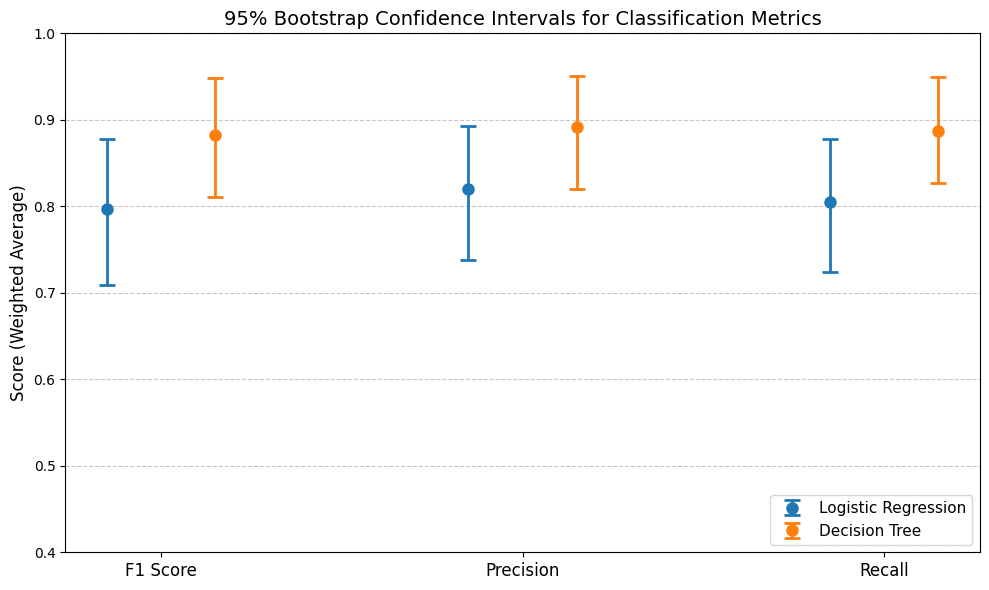

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

models = results_df['Model'].unique()
metrics_list = results_df['Metric'].unique()

x_positions = np.arange(len(metrics_list))
width = 0.2  

for i, model in enumerate(models):
    subset = results_df[results_df['Model'] == model]
    offset = (i - 0.5) * width * 1.5 

    ax.errorbar(
        x_positions + offset, subset['Mean'], 
        yerr=[subset['Err_Lower'], subset['Err_Upper']], 
        fmt='o', label=model, capsize=6, capthick=2, elinewidth=2, markersize=8
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(metrics_list, fontsize=12)
ax.set_ylabel('Score (Weighted Average)', fontsize=12)
ax.set_title('95% Bootstrap Confidence Intervals for Classification Metrics', fontsize=14)
ax.set_ylim(0.4, 1.0) 
ax.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Recommendation

*Which model would you recommend? How confident are you based on the CIs?*
I recommend decision tree model because its scores are higher than logistic regression's and its whisker are narrower

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

### Your Summary

The strongest pattern in the data shows that weight is the biggest enemy of fuel efficiency. heavier cars need a lot more energy to get moving and stay moving, which means they burn a lot more fuel.

It is a similar for engine size and horsepower. Cars with big, powerful engines might be fast, but those big engines require a massive amount of gas to create that power. So, if you want a car that gets great gas mileage, you generally have to trade away raw power and accept a smaller, lighter vehicle.

This trade-off perfectly explains the differences we see between cars from different parts of the world during that era. American cars were typically the heaviest and had the biggest, most powerful engines, making them the worst performers when it came to fuel efficiency. On the other hand, Japanese cars were built to be much smaller and lighter with less powerful engines, which is why they easily took the top spot for the best gas mileage. European cars sat right in the middle, balancing moderate size and power with decent fuel economy.